In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 0. Understanding the Data

3 Folders

- test
- train
  - Folder Structure
    - tdcsfog/ (data series collected in the lab)
    - defog/ (data series collected in subject's home)
    - notype/ (data series from the defog dataset but lack event-type annotations)
  - Columns
    |Column | Description | tdcsfog | defog | notype |
    |-------|-------------|---------|-------|--------|
    | Time | Time | ✅ (Recodrded at 128 Hz) | ✅ (Recorded at 100 Hz) | ✅ (Recorded at 100 Hz)
    |AccV | Vertical (Unit - $m/s^2$)| ✅ | ✅ | ✅
    |AccML | MedioLateral (Unit - $m/s^2$)| ✅| ✅ | ✅
    |AccAP | AnteroPosterior (Unit - $m/s^2$)| ✅| ✅ | ✅
    |StartHesitation | Event | ✅| ✅ |
    | Turn | Event | ✅ | ✅ |
    | Walking | Event | ✅| ✅ |
    | Event | Indicator Variable for the occurence of an FoG type event | | |✅
    | Valid | If event annotation is ambiguos (True if ambiguos) | | ✅| ✅
    | Task | | | ✅| ✅
- unlabeled


## 1. Reading Data


In [62]:
df_tdcsfog = pd.read_csv(
    "C:/Users/Tanay Yeole/Documents/My_Projects/FoG/data/raw/tlvmc-parkinsons-freezing-gait-prediction/train/tdcsfog/2365c918c9.csv"
)

In [25]:
df_tdcsfog.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking
0,0,-9.707204,-1.224652,-0.683524,0,0,0
1,1,-9.707674,-1.211399,-0.669773,0,0,0
2,2,-9.696156,-1.213643,-0.669768,0,0,0
3,3,-9.707434,-1.220285,-0.665187,0,0,0
4,4,-9.709863,-1.206813,-0.639973,0,0,0


In [9]:
df_defog = pd.read_csv(
    "C:/Users/Tanay Yeole/Documents/My_Projects/FoG/data/raw/tlvmc-parkinsons-freezing-gait-prediction/train/defog/0c55be4384.csv"
)
df_defog.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Valid,Task
0,0,-1.017303,0.105948,-0.067194,0,0,0,False,False
1,1,-1.019972,0.105369,-0.068920,0,0,0,False,False
2,2,-1.017942,0.103586,-0.069410,0,0,0,False,False
3,3,-1.017090,0.102103,-0.070308,0,0,0,False,False
4,4,-1.017065,0.104719,-0.070091,0,0,0,False,False


In [10]:
df_notype = pd.read_csv(
    "C:/Users/Tanay Yeole/Documents/My_Projects/FoG/data/raw/tlvmc-parkinsons-freezing-gait-prediction/train/notype/0a900ed8a2.csv"
)
df_notype.head()

,Time,AccV,AccML,AccAP,Event,Valid,Task
0,0,-0.876855,-0.071298,0.473350,0,False,False
1,1,-0.877627,-0.071626,0.472676,0,False,False
2,2,-0.876412,-0.072453,0.473145,0,False,False
3,3,-0.877211,-0.073387,0.473575,0,False,False
4,4,-0.878722,-0.072186,0.474908,0,False,False


In [12]:
# Calulate the number of files present in each folder
path_to_directory = "C:/Users/Tanay Yeole/Documents/My_Projects/FoG/data/raw/tlvmc-parkinsons-freezing-gait-prediction/train/"
folders = ["tdcsfog", "defog", "notype"]
num_files = {}
for folder in folders:
    num_files[folder] = len(
        [
            name
            for name in os.listdir(path_to_directory + folder)
            if os.path.isfile(os.path.join(path_to_directory + folder, name))
        ]
    )

In [13]:
num_files

{'tdcsfog': 833, 'defog': 91, 'notype': 46}

In [3]:
tdcsfog_metadata = pd.read_csv(
    "C:/Users/Tanay Yeole/Documents/My_Projects/FoG/data/raw/tlvmc-parkinsons-freezing-gait-prediction/tdcsfog_metadata.csv"
)
tdcsfog_metadata.head()

,Id,Subject,Visit,Test,Medication
0,003f117e14,4dc2f8,3,2,on
1,009ee11563,f62eec,4,2,on
2,011322847a,231c3b,2,2,on
3,01d0fe7266,231c3b,2,1,off
4,024418ba39,fa8764,19,3,on


In [4]:
tdcsfog_metadata

,Id,Subject,Visit,Test,Medication
0,003f117e14,4dc2f8,3,2,on
1,009ee11563,f62eec,4,2,on
2,011322847a,231c3b,2,2,on
3,01d0fe7266,231c3b,2,1,off
4,024418ba39,fa8764,19,3,on
...,...,...,...,...,...
828,feba449e1a,312788,19,1,on
829,ff4f844fd3,af82b2,2,3,on
830,ff53514514,3b2403,2,3,on
831,ff92d9244d,2d57c2,20,2,on


In [30]:
df_events = pd.read_csv(
    "C:/Users/Tanay Yeole/Documents/My_Projects/FoG/data/raw/tlvmc-parkinsons-freezing-gait-prediction/events.csv"
)

In [32]:
df_events.head()

,Id,Init,Completion,Type,Kinetic
0,003f117e14,8.61312,14.7731,Turn,1.0
1,009ee11563,11.38470,41.1847,Turn,1.0
2,009ee11563,54.66470,58.7847,Turn,1.0
3,011322847a,28.09660,30.2966,Turn,1.0
4,01d0fe7266,30.31840,31.8784,Turn,1.0


## Visualizing tdcsfog for a single patient


In [63]:
def label_activity(row):
    if row["StartHesitation"] == 1:
        return "StartHesitation"
    elif row["Turn"] == 1:
        return "Turn"
    elif row["Walking"] == 1:
        return "Walking"
    else:
        return "None"


df_tdcsfog["Activity"] = df_tdcsfog.apply(label_activity, axis=1)

In [64]:
# Mark the beginning of a new segment when activity changes
df_tdcsfog["Activity_Change"] = (
    df_tdcsfog["Activity"] != df_tdcsfog["Activity"].shift()
).cumsum()

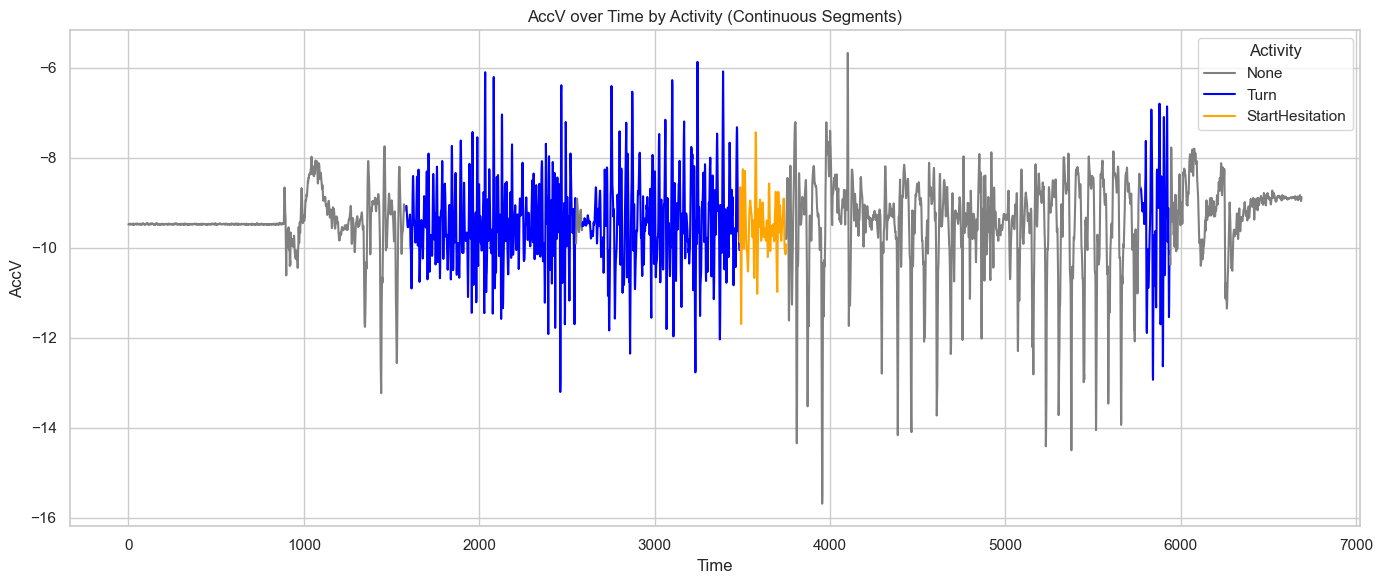

In [54]:
import matplotlib.pyplot as plt

# Define custom colors for each activity
color_map = {
    "None": "gray",
    "StartHesitation": "orange",
    "Turn": "blue",
    "Walking": "green",
}

plt.figure(figsize=(14, 6))

# Plot each continuous segment separately
for _, segment in df_tdcsfog.groupby("Activity_Change"):
    activity = segment["Activity"].iloc[0]
    plt.plot(
        segment["Time"], segment["AccV"], color=color_map[activity], label=activity
    )

# Handle legend (avoid duplicate labels)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Activity")

plt.title("AccV over Time by Activity (Continuous Segments)")
plt.xlabel("Time")
plt.ylabel("AccV")
plt.tight_layout()
plt.show()

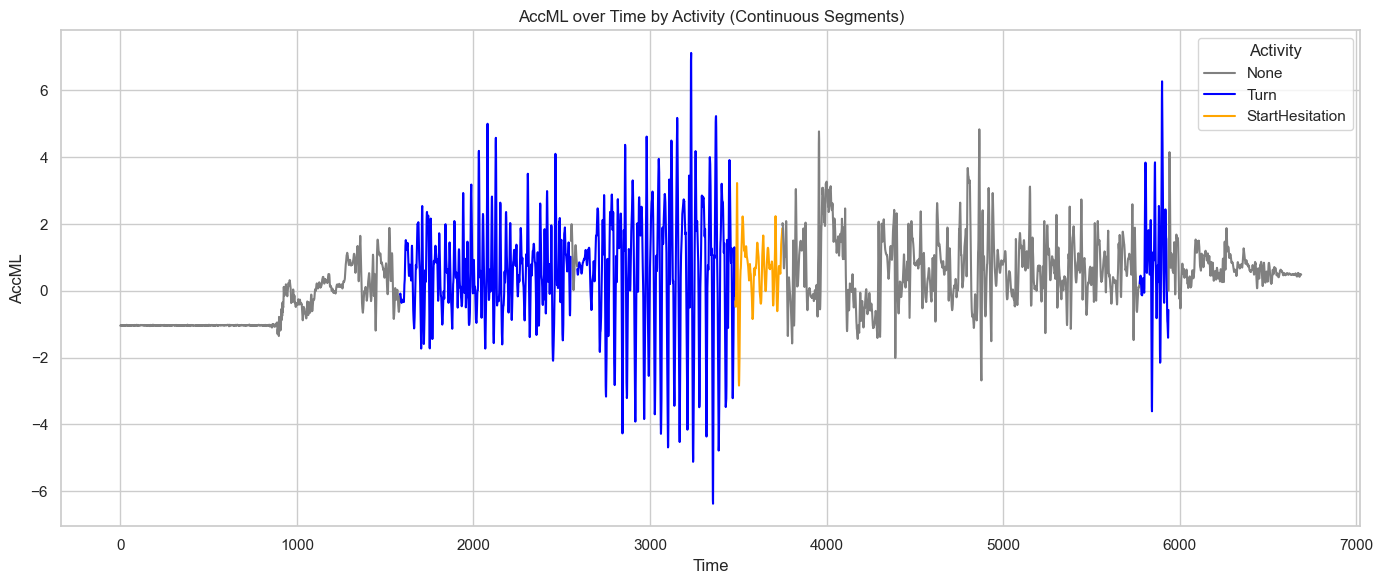

In [55]:
import matplotlib.pyplot as plt

# Define custom colors for each activity
color_map = {
    "None": "gray",
    "StartHesitation": "orange",
    "Turn": "blue",
    "Walking": "green",
}

plt.figure(figsize=(14, 6))

# Plot each continuous segment separately
for _, segment in df_tdcsfog.groupby("Activity_Change"):
    activity = segment["Activity"].iloc[0]
    plt.plot(
        segment["Time"], segment["AccML"], color=color_map[activity], label=activity
    )

# Handle legend (avoid duplicate labels)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Activity")

plt.title("AccML over Time by Activity (Continuous Segments)")
plt.xlabel("Time")
plt.ylabel("AccML")
plt.tight_layout()
plt.show()

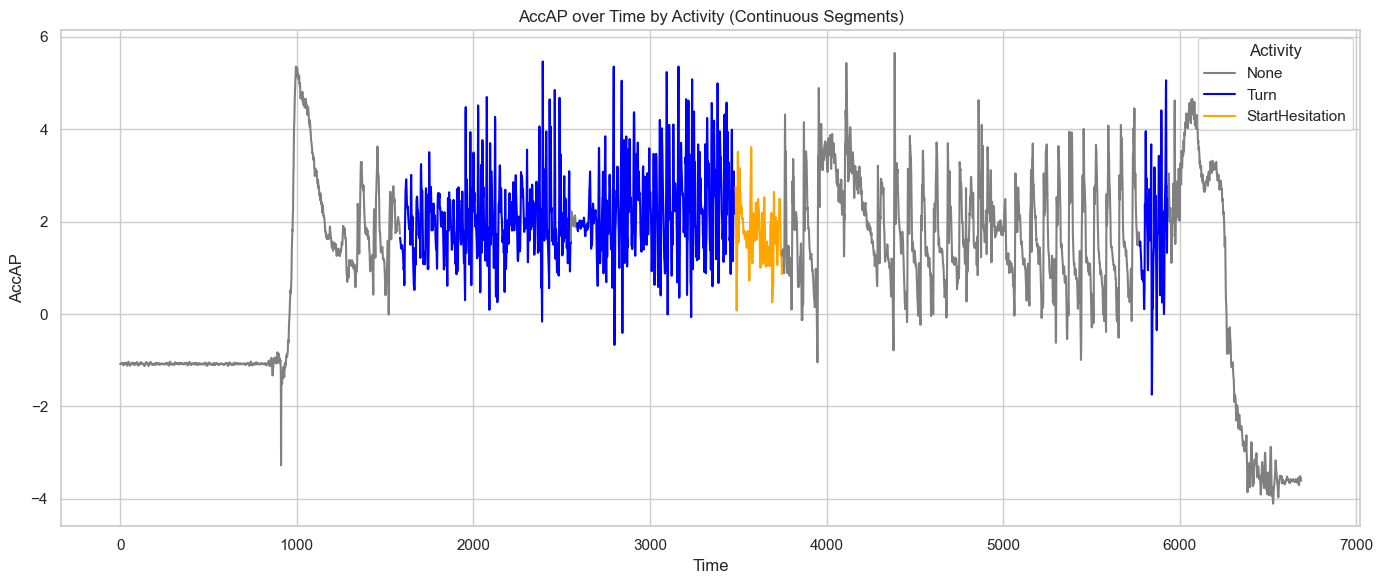

In [ ]:
import matplotlib.pyplot as plt

# Define custom colors for each activity
color_map = {
    "None": "gray",
    "StartHesitation": "orange",
    "Turn": "blue",
    "Walking": "green",
}

plt.figure(figsize=(14, 6))

# Plot each continuous segment separately
for _, segment in df_tdcsfog.groupby("Activity_Change"):
    activity = segment["Activity"].iloc[0]
    plt.plot(
        segment["Time"], segment["AccAP"], color=color_map[activity], label=activity
    )

# Handle legend (avoid duplicate labels)
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), title="Activity")

plt.title("AccAP over Time by Activity (Continuous Segments)")
plt.xlabel("Time")
plt.ylabel("AccAP")
plt.tight_layout()
plt.show()

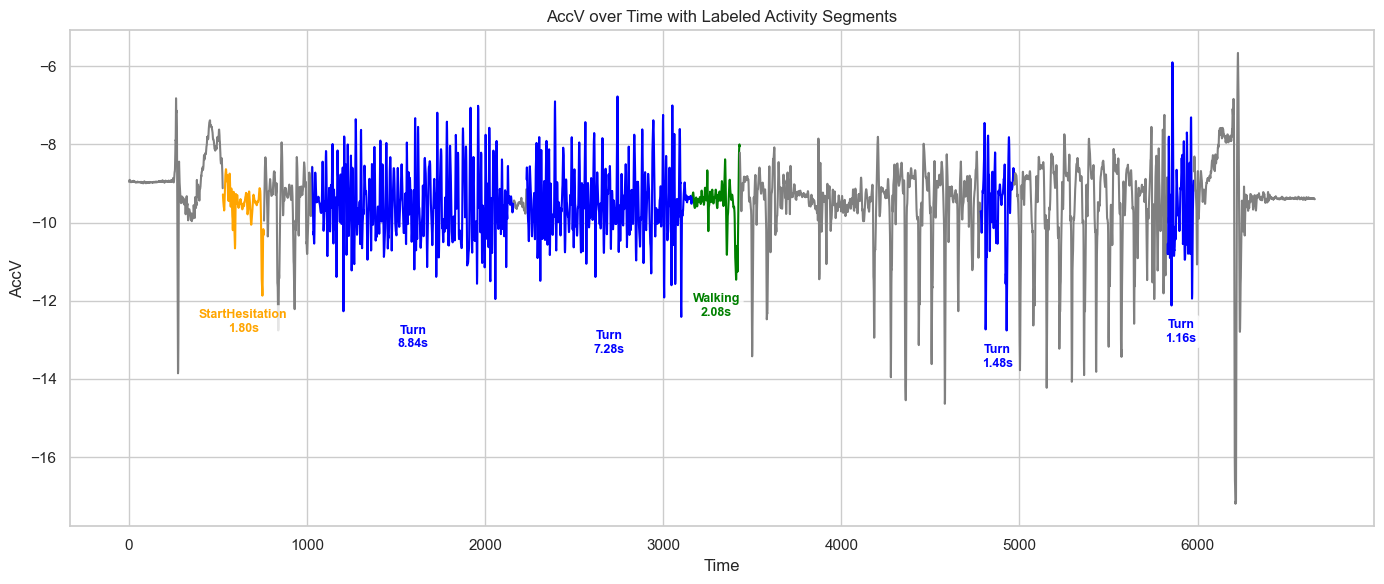

In [65]:
import matplotlib.pyplot as plt

# Color map
color_map = {
    "None": "gray",
    "StartHesitation": "orange",
    "Turn": "blue",
    "Walking": "green",
}


# Label activities
def label_activity(row):
    if row["StartHesitation"] == 1:
        return "StartHesitation"
    elif row["Turn"] == 1:
        return "Turn"
    elif row["Walking"] == 1:
        return "Walking"
    else:
        return "None"


df_tdcsfog["Activity"] = df_tdcsfog.apply(label_activity, axis=1)
df_tdcsfog["Activity_Change"] = (
    df_tdcsfog["Activity"] != df_tdcsfog["Activity"].shift()
).cumsum()

# Plotting
plt.figure(figsize=(14, 6))

for _, segment in df_tdcsfog.groupby("Activity_Change"):
    activity = segment["Activity"].iloc[0]
    time = segment["Time"]
    accv = segment["AccV"]

    # Plot segment line
    plt.plot(time, accv, color=color_map[activity], linewidth=1.5)

    if activity != "None":
        duration_sec = len(segment) / 128
        mid_idx = len(segment) // 2
        mid_time = time.iloc[mid_idx]

        # Place label just above max AccV in the segment
        y_pos = accv.min() - 1  # add some buffer above the max

        plt.text(
            mid_time,
            y_pos,
            f"{activity}\n{duration_sec:.2f}s",
            ha="center",
            va="bottom",
            fontsize=9,
            color=color_map[activity],
            weight="bold",
            bbox=dict(
                facecolor="white", edgecolor="none", alpha=0.8, boxstyle="round,pad=0.3"
            ),
        )

# Final formatting
plt.title("AccV over Time with Labeled Activity Segments")
plt.xlabel("Time")
plt.ylabel("AccV")
plt.tight_layout()
plt.show()

In [68]:
len(df_events[df_events["Type"] == "StartHesitation"])

107

In [69]:
len(df_events[df_events["Type"] == "Walking"])

398

In [70]:
len(df_events[df_events["Type"] == "Turn"])

1997

In [71]:
len(df_events[df_events["Type"] == "None"])

0